In [ ]:
#!pip install -U icechunk obstore git+https://github.com/zarr-developers/virtualizarr.git@fix/problem_fillvalues

In [ ]:
import earthaccess
import xarray as xr

from obstore.auth.earthdata import NasaEarthdataCredentialProvider

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import helpers

# Find GPM IMERG HH Granules

In [8]:
earthaccess.login()

In [9]:
collection_short_name = 'GPM_3IMERGHH'
collection_version = '07'

In [10]:
granules = earthaccess.search_data(
    short_name=collection_short_name,
    version=collection_version,
    cloud_hosted=True,
    count=10
)

In [11]:
sorted_granules = sorted(
    granules,
    key=lambda g: g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime']
)

In [12]:
first_granule = sorted_granules[0]

In [13]:
first_link = first_granule.data_links(access='direct')[0]

In [ ]:
# Obtain an S3 credentials URL and an S3 data/download URL, typically
# via metadata returned from a NASA CMR collection or granule query.
credentials_url = "https://data.gesdisc.earthdata.nasa.gov/s3credentials"
# Since no NASA Earthdata credentials are specified in this example,
# environment variables or netrc will be used to locate them in order to
# obtain S3 credentials from the URL.
cp = NasaEarthdataCredentialProvider(credentials_url)

In [ ]:
virtual_store_path = first_link.rsplit('/', 1)[0]
repo = helpers.open_or_create_repo(virtual_chunk_url=first_link)

  2026-05-16T17:53:50.720997Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



In [ ]:
vds = helpers.open_vds_with_coords(first_link)

In [ ]:
session = repo.writable_session("main")
vds.vz.to_icechunk(session.store)

In [ ]:
session.commit("initial file")

In [ ]:
second_link = granules[1].data_links(access='direct')[0]
vds2 = helpers.open_vds(second_link)

In [ ]:
vds2

In [ ]:
session = repo.writable_session("main")
vds2.vz.to_icechunk(session.store, append_dim='time')
session.commit("wrote second file")

# Test it

In [16]:
session = repo.readonly_session("main")
ds = xr.open_zarr(session.store, zarr_format=3)
ds

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 207MB
Dimensions:                         (time: 2, lon: 3600, lat: 1800, latv: 2,
                                     nv: 2, lonv: 2)
Coordinates:
  * time                            (time) object 16B 1998-01-01 00:00:00 199...
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float32 7kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: latv, nv, lonv
Data variables:
    probabilityLiquidPrecipitation  (time, lon, lat) float32 52MB dask.array<chunksize=(1, 291, 1800), meta=np.ndarray>
    lat_bnds                        (lat, latv) float32 14kB dask.array<chunksize=(1800, 2), meta=np.ndarray>
    randomError                     (time, lon, lat) float32 52MB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    time_bnds                       (time, nv) object 32B dask.array<chunksize=(2, 2), meta=np.ndarray>
    precipitationQualityIndex       (time, lon, lat) float32 52MB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    precipitation                   (time, lon, lat) float32 52MB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    lon_bnds                        (lon, lonv) float32 29kB dask.array<chunksize=(3600, 2), meta=np.ndarray>
Attributes:
    GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegistration=CENTER;\nLatitudeRe...

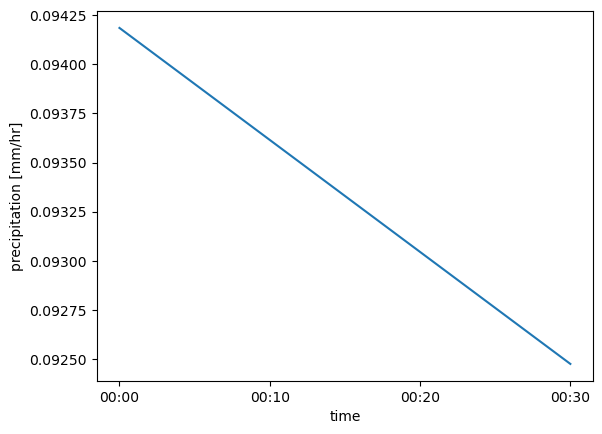

In [17]:
# Average over lat and lon dimensions
precip_mean = ds['precipitation'].mean(dim=['lat', 'lon'])

# Plot
precip_mean.plot()

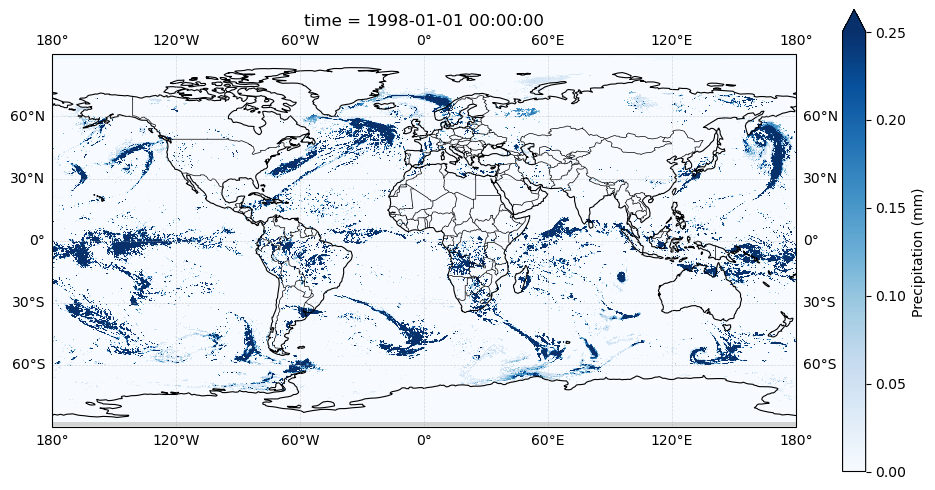

In [18]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

data = ds['precipitation'].isel(time=0).transpose('lat', 'lon')

vmin = float(data.quantile(0.05))
vmax = float(data.quantile(0.95))

data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={'label': 'Precipitation (mm)'}
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)  # land background
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', zorder=0) # ocean background
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.5)

plt.show()